In [ ]:
!ls -F /content/brain-tumor-mri-dataset/

glioma/  meningioma/  notumor/	pituitary/


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
!unzip archive.zip

A saída de streaming foi truncada nas últimas 5000 linhas.
  inflating: brain-tumor-mri-dataset/meningioma/me-0533.jpg  
  inflating: brain-tumor-mri-dataset/meningioma/me-0534.jpg  
  inflating: brain-tumor-mri-dataset/meningioma/me-0535.jpg  
  inflating: brain-tumor-mri-dataset/meningioma/me-0536.jpg  
  inflating: brain-tumor-mri-dataset/meningioma/me-0537.jpg  
  inflating: brain-tumor-mri-dataset/meningioma/me-0538.jpg  
  inflating: brain-tumor-mri-dataset/meningioma/me-0539.jpg  
  inflating: brain-tumor-mri-dataset/meningioma/me-0540.jpg  
  inflating: brain-tumor-mri-dataset/meningioma/me-0541.jpg  
  inflating: brain-tumor-mri-dataset/meningioma/me-0542.jpg  
  inflating: brain-tumor-mri-dataset/meningioma/me-0543.jpg  
  inflating: brain-tumor-mri-dataset/meningioma/me-0544.jpg  
  inflating: brain-tumor-mri-dataset/meningioma/me-0545.jpg  
  inflating: brain-tumor-mri-dataset/meningioma/me-0546.jpg  
  inflating: brain-tumor-mri-dataset/meningioma/me-0547.jpg  
  inflating

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [ ]:
classes = [
    "glioma",
    "meningioma",
    "pituitary",
    "notumor"
]

X = []
y = []

base_path = "/content/content/brain-tumor-mri-dataset"

In [ ]:
for label, classe in enumerate(classes):

    pasta = os.path.join(base_path, classe)

    for arquivo in os.listdir(pasta):

        caminho = os.path.join(pasta, arquivo)

        img = cv2.imread(
            caminho,
            cv2.IMREAD_GRAYSCALE
        )

        img = cv2.resize(img, (64,64))

        vetor = img.flatten()

        X.append(vetor)

        y.append(label)

In [ ]:
X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

(7153, 4096)
(7153,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
modelo = GaussianNB()

modelo.fit(
    X_train,
    y_train
)

GaussianNB()

In [ ]:
pred = modelo.predict(X_test)

In [ ]:
acc = accuracy_score(
    y_test,
    pred
)

print("Acurácia:", acc)

Acurácia: 0.5946890286512928


In [ ]:
cm = confusion_matrix(
    y_test,
    pred
)

print(cm)

[[292  10  22   0]
 [213  68  30  44]
 [ 58  16 276   2]
 [ 52 106  27 215]]


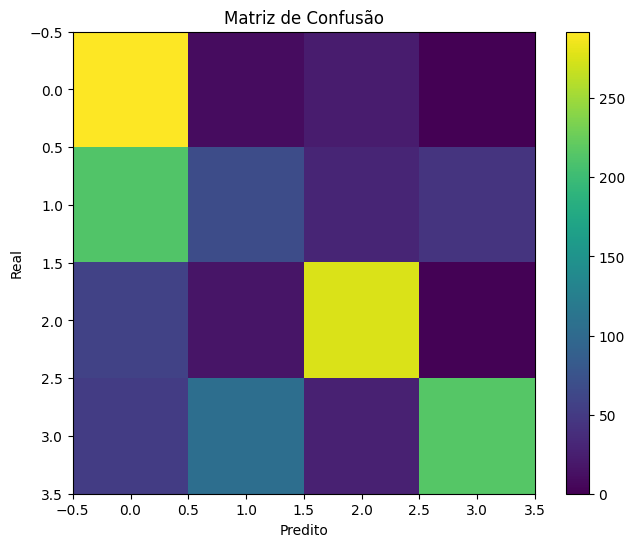

In [ ]:
plt.figure(figsize=(8,6))

plt.imshow(cm)

plt.colorbar()

plt.title("Matriz de Confusão")

plt.xlabel("Predito")

plt.ylabel("Real")

plt.show()

In [ ]:
print(
    classification_report(
        y_test,
        pred,
        target_names=classes
    )
)

              precision    recall  f1-score   support

      glioma       0.47      0.90      0.62       324
  meningioma       0.34      0.19      0.25       355
   pituitary       0.78      0.78      0.78       352
     notumor       0.82      0.54      0.65       400

    accuracy                           0.59      1431
   macro avg       0.60      0.60      0.57      1431
weighted avg       0.61      0.59      0.58      1431



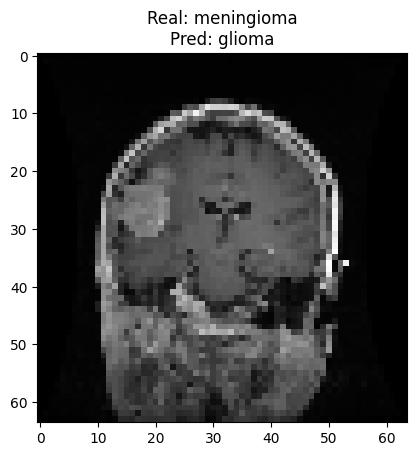

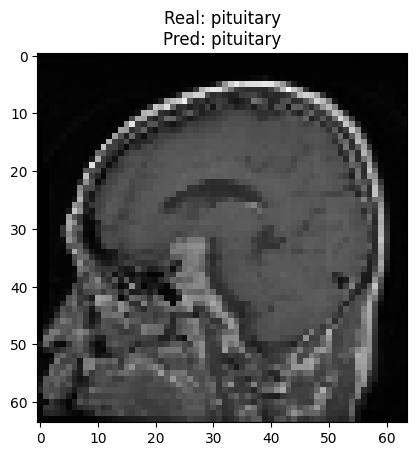

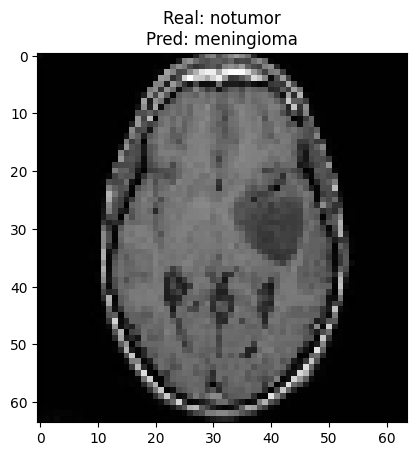

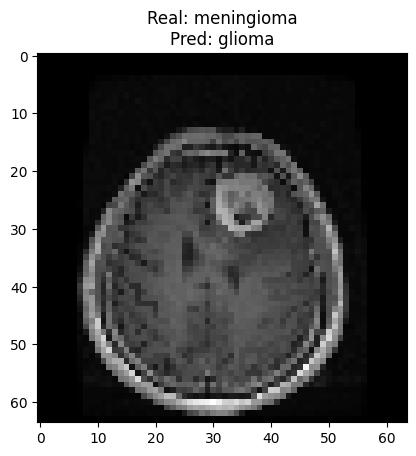

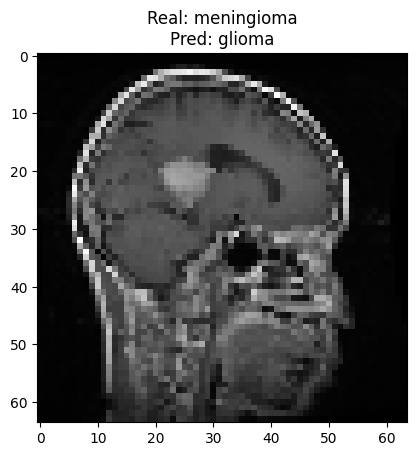

In [ ]:
for i in range(5):

    plt.imshow(
        X_test[i].reshape(64,64),
        cmap="gray"
    )

    plt.title(
        f"Real: {classes[y_test[i]]}\nPred: {classes[pred[i]]}"
    )

    plt.show()

Classificação de Tumores Cerebrais Utilizando Naive Bayes
Objetivo

O objetivo deste trabalho foi implementar o algoritmo Gaussian Naive Bayes para a classificação de tumores cerebrais utilizando imagens de ressonância magnética (MRI). O modelo foi treinado e avaliado com um conjunto de imagens contendo diferentes tipos de tumores cerebrais e imagens sem tumor.

Dataset Utilizado

Foi utilizado o dataset "Brain Tumor MRI Dataset", disponibilizado na plataforma Kaggle. O conjunto de dados é composto por imagens de ressonância magnética organizadas em quatro classes:

Glioma
Meningioma
Pituitary
No Tumor

As imagens foram convertidas para escala de cinza, redimensionadas para 64x64 pixels e transformadas em vetores numéricos para que pudessem ser utilizadas pelo algoritmo Gaussian Naive Bayes.

Metodologia

Inicialmente, as imagens foram carregadas e processadas utilizando a biblioteca OpenCV. Após o pré-processamento, cada imagem foi convertida em um vetor de características contendo 4096 atributos (64 x 64 pixels).

O conjunto final de dados apresentou as seguintes dimensões:

Total de imagens: 7153
Total de atributos por imagem: 4096

Formato dos dados:

X = (7153, 4096)
y = (7153,)

Em seguida, os dados foram divididos em conjuntos de treinamento e teste utilizando a proporção de 80% para treinamento e 20% para teste.

O modelo utilizado foi o Gaussian Naive Bayes, implementado por meio da biblioteca Scikit-Learn.

Resultados
Acurácia

O modelo obteve uma acurácia de:

59,47%

Valor calculado:

Accuracy = 0.594689

Embora o resultado seja moderado, é importante destacar que o algoritmo Naive Bayes não é o método mais adequado para classificação de imagens, pois assume independência entre os atributos. Em problemas de visão computacional, modelos baseados em Redes Neurais Convolucionais (CNNs) geralmente apresentam desempenho significativamente superior.

Matriz de Confusão
[[292  10  22   0]
 [213  68  30  44]
 [ 58  16 276   2]
 [ 52 106  27 215]]

A matriz de confusão demonstra que o modelo apresentou melhor desempenho na identificação das classes "Pituitary" e "No Tumor", enquanto encontrou maior dificuldade na classificação correta dos casos de "Meningioma".

Relatório de Classificação
Classe	Precisão	Recall	F1-Score
Glioma	0.47	0.90	0.62
Meningioma	0.34	0.19	0.25
Pituitary	0.78	0.78	0.78
No Tumor	0.82	0.54	0.65

Médias gerais:

Accuracy: 0.59
Macro Average F1-Score: 0.57
Weighted Average F1-Score: 0.58
Discussão

Os resultados demonstram que o algoritmo Gaussian Naive Bayes foi capaz de identificar padrões nas imagens de ressonância magnética, obtendo desempenho satisfatório em algumas classes específicas, especialmente "Pituitary" e "No Tumor".

Entretanto, observou-se uma queda significativa no desempenho para a classe "Meningioma", indicando dificuldade do modelo em distinguir esse tipo de tumor das demais categorias presentes no conjunto de dados.

Esse comportamento era esperado, pois o Naive Bayes não foi desenvolvido especificamente para tarefas de classificação de imagens. Como cada pixel é tratado como uma característica independente, o modelo não consegue explorar adequadamente padrões espaciais complexos existentes nas imagens médicas.

Conclusão

Neste trabalho foi implementado o algoritmo Gaussian Naive Bayes para classificação de tumores cerebrais em imagens de ressonância magnética. O modelo alcançou uma acurácia de aproximadamente 59,47%, demonstrando que é possível utilizar técnicas clássicas de Machine Learning para essa tarefa.

Apesar dos resultados obtidos, métodos mais avançados, como Redes Neurais Convolucionais (CNNs), ResNet e EfficientNet, tendem a apresentar desempenho superior devido à sua capacidade de extrair automaticamente características relevantes das imagens.

Como trabalho futuro, recomenda-se comparar o desempenho do Naive Bayes com arquiteturas modernas de Deep Learning para avaliar o ganho de desempenho na classificação automática de tumores cerebrais.